In [21]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, BatchNormalization
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import pickle
import json
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
base_path = "/content/drive/MyDrive/"  # change if needed

X_train = np.load(base_path + "X_train.npy")
X_val   = np.load(base_path + "X_val.npy")
X_test  = np.load(base_path + "X_test.npy")

y_train = np.load(base_path + "y_train.npy")
y_val   = np.load(base_path + "y_val.npy")
y_test  = np.load(base_path + "y_test.npy")

print(X_train.shape, y_train.shape)
print(np.unique(y_train))

(402542, 50) (402542,)
[0 1]


In [5]:
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(0): np.int64(390740), np.int64(1): np.int64(11802)}


In [6]:
vocab_size = int(np.max(X_train)) + 1
max_len = 50

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),

    LSTM(128, return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),

    LSTM(64),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

In [8]:
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))
print(class_weights)

{np.int64(0): np.float64(0.5151021139376567), np.int64(1): np.float64(17.05397390272835)}


In [9]:
callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ReduceLROnPlateau(patience=2)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/20
3145/3145 ━━━━━━━━━━━━━━━━━━━━ 58s 15ms/step - accuracy: 0.9672 - loss: 0.0700 - precision: 0.4713 - recall: 0.9796 - val_accuracy: 0.9966 - val_loss: 0.0200 - val_precision: 0.8925 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/20
3145/3145 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - accuracy: 0.9964 - loss: 0.0140 - precision: 0.8909 - recall: 0.9993 - val_accuracy: 0.9966 - val_loss: 0.0203 - val_precision: 0.8925 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/20
3145/3145 ━━━━━━━━━━━━━━━━━━━━ 47s 15ms/step - accuracy: 0.9965 - loss: 0.0118 - precision: 0.8942 - recall: 1.0000 - val_accuracy: 0.9966 - val_loss: 0.0142 - val_precision: 0.8925 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/20
3145/3145 ━━━━━━━━━━━━━━━━━━━━ 49s 16ms/step - accuracy: 0.9964 - loss: 0.0132 - precision: 0.8926 - recall: 0.9990 - val_accuracy: 0.9966 - val_loss: 0.0062 - val_precision: 0.8945 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 5/20
3145/3145 ━━━━━━━━━━━━━━━━━━━━ 47s 15

In [10]:
model.save("/content/drive/MyDrive/llstm_model(v1).h5")

In [12]:
base_path = "/content/drive/MyDrive/"
prefix = "LSTM_model_v1_"

# 🔹 1. Save training history
with open(base_path + prefix + "history.pkl", "wb") as f:
    pickle.dump(history.history, f)

# 🔹 2. Save predictions (train + validation)
y_train_pred_prob = model.predict(X_train, batch_size=256)
y_val_pred_prob   = model.predict(X_val, batch_size=256)

np.save(base_path + prefix + "y_train_pred_prob.npy", y_train_pred_prob)
np.save(base_path + prefix + "y_val_pred_prob.npy", y_val_pred_prob)

# 🔹 3. Save true labels
np.save(base_path + prefix + "y_train_true.npy", y_train)
np.save(base_path + prefix + "y_val_true.npy", y_val)

# 🔹 4. Save threshold
threshold = 0.5
with open(base_path + prefix + "threshold.json", "w") as f:
    json.dump({"threshold": threshold}, f)

# 🔹 5. Save summary metrics
final_metrics = {
    "train_accuracy": history.history["accuracy"][-1],
    "train_precision": history.history["precision"][-1],
    "train_recall": history.history["recall"][-1],
    "val_accuracy": history.history["val_accuracy"][-1],
    "val_precision": history.history["val_precision"][-1],
    "val_recall": history.history["val_recall"][-1],
}

with open(base_path + prefix + "metrics_summary.json", "w") as f:
    json.dump(final_metrics, f, indent=4)

print("✅ All training & validation data saved with version: LSTM_model_v1")

1573/1573 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step
337/337 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
✅ All training & validation data saved with version: LSTM_model_v1


In [15]:
base_path = "/content/drive/MyDrive/"
prefix = "LSTM_model_v1_"

# Load history
with open(base_path + prefix + "history.pkl", "rb") as f:
    history = pickle.load(f)

# Load predictions
y_train_pred_prob = np.load(base_path + prefix + "y_train_pred_prob.npy")
y_val_pred_prob   = np.load(base_path + prefix + "y_val_pred_prob.npy")

# Load true labels
y_train = np.load(base_path + prefix + "y_train_true.npy")
y_val   = np.load(base_path + prefix + "y_val_true.npy")

# Load threshold
with open(base_path + prefix + "threshold.json", "r") as f:
    threshold = json.load(f)["threshold"]

print("✅ Data loaded successfully")

✅ Data loaded successfully


In [16]:
y_train_pred = (y_train_pred_prob > threshold).astype(int)
y_val_pred   = (y_val_pred_prob > threshold).astype(int)

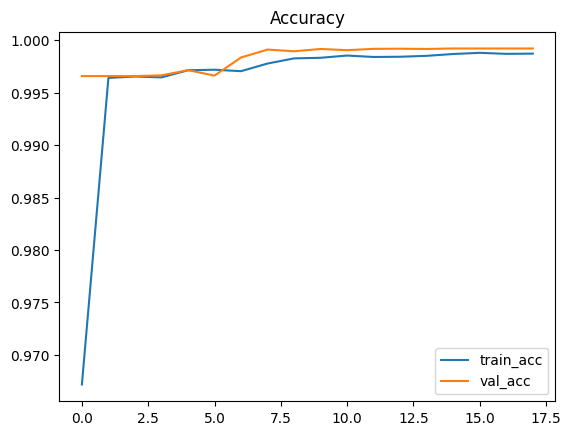

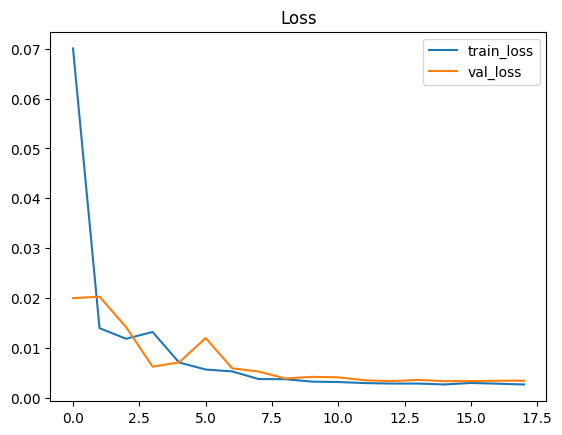

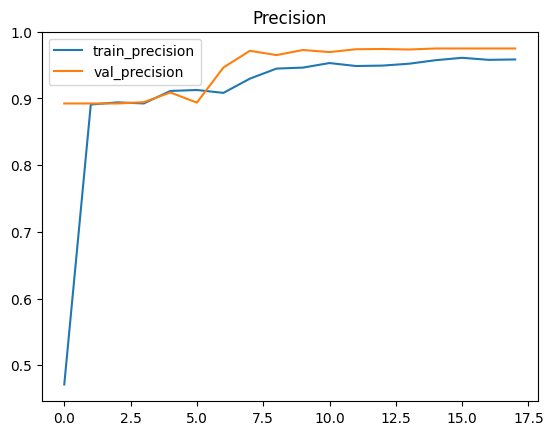

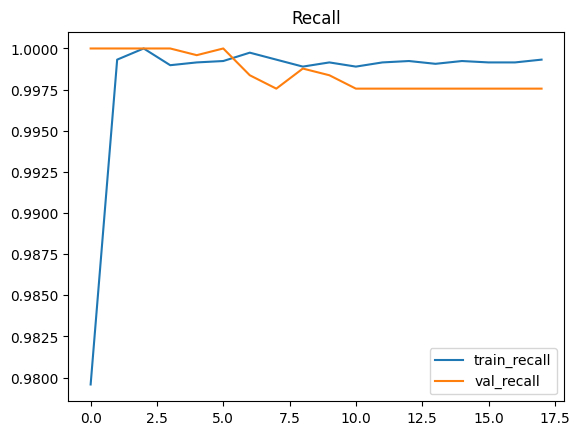

In [18]:
# Accuracy
plt.plot(history["accuracy"], label="train_acc")
plt.plot(history["val_accuracy"], label="val_acc")
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history["loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss")
plt.show()

# Precision
plt.plot(history["precision"], label="train_precision")
plt.plot(history["val_precision"], label="val_precision")
plt.legend()
plt.title("Precision")
plt.show()

# Recall
plt.plot(history["recall"], label="train_recall")
plt.plot(history["val_recall"], label="val_recall")
plt.legend()
plt.title("Recall")
plt.show()

In [20]:
print("=== TRAIN METRICS ===")
print(confusion_matrix(y_train, y_train_pred))
print(classification_report(y_train, y_train_pred))
print("F1:", f1_score(y_train, y_train_pred))

print("\n=== VALIDATION METRICS ===")
print(confusion_matrix(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))
print("F1:", f1_score(y_val, y_val_pred))

=== TRAIN METRICS ===
[[390499    241]
 [    17  11785]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    390740
           1       0.98      1.00      0.99     11802

    accuracy                           1.00    402542
   macro avg       0.99      1.00      0.99    402542
weighted avg       1.00      1.00      1.00    402542

F1: 0.9891724022158804

=== VALIDATION METRICS ===
[[83738    63]
 [    6  2452]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     83801
           1       0.97      1.00      0.99      2458

    accuracy                           1.00     86259
   macro avg       0.99      1.00      0.99     86259
weighted avg       1.00      1.00      1.00     86259

F1: 0.9861250754071988


In [25]:
X_test = np.load("/content/drive/MyDrive/X_test.npy")
y_test = np.load("/content/drive/MyDrive/y_test.npy")
y_test_pred_prob = model.predict(X_test, batch_size=256)
y_test_pred = (y_test_pred_prob > threshold).astype(int)

337/337 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [26]:
print("=== TEST CONFUSION MATRIX ===")
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

print("\n=== TEST CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_test_pred))

print("Test F1 Score:", f1_score(y_test, y_test_pred))

=== TEST CONFUSION MATRIX ===
[[83631    51]
 [    3  2575]]

=== TEST CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     83682
           1       0.98      1.00      0.99      2578

    accuracy                           1.00     86260
   macro avg       0.99      1.00      0.99     86260
weighted avg       1.00      1.00      1.00     86260

Test F1 Score: 0.9896233666410453


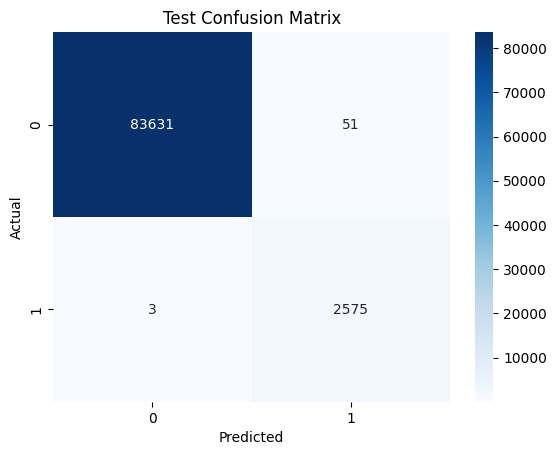

In [27]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()